In [1]:
pip install SimpleITK

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk
from pathlib import Path
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

2026-02-04 03:59:16.019591: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770177556.199909    1671 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770177556.252031    1671 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770177556.688986    1671 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770177556.689031    1671 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770177556.689033    1671 computation_placer.cc:177] computation placer alr

In [3]:
SUBSET_PATH = '/kaggle/input/luna16/subset0/subset0'
CANDIDATES_PATH = '/kaggle/input/luna16/candidates_V2/candidates_V2.csv'
ANNOTATIONS_PATH = '/kaggle/input/luna16/annotations.csv'

# 1. Data Exploratory

In [4]:
annotations_df = pd.read_csv(ANNOTATIONS_PATH)
candidates_df = pd.read_csv(CANDIDATES_PATH)

print("Annotations shape:", annotations_df.shape)
print("\nAnnotations columns:")
print(annotations_df.head())

print("\nCandidates shape:", candidates_df.shape)
print("\nCandidates columns:")
print(candidates_df.head())

Annotations shape: (1186, 5)

Annotations columns:
                                           seriesuid      coordX      coordY  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222... -128.699421 -175.319272   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  103.783651 -211.925149   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...   69.639017 -140.944586   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...  -24.013824  192.102405   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...    2.441547  172.464881   

       coordZ  diameter_mm  
0 -298.387506     5.651471  
1 -227.121250     4.224708  
2  876.374496     5.786348  
3 -391.081276     8.143262  
4 -405.493732    18.545150  

Candidates shape: (754975, 5)

Candidates columns:
                                           seriesuid     coordX      coordY  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  68.420000  -74.480000   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222... -95.209361  -91.809406   
2  1.

In [5]:
mhd_files = list(Path(SUBSET_PATH).glob('*.mhd'))
print(f"Number of CT scans in subset0: {len(mhd_files)}")
print("\nFirst 5 scans:")
for f in mhd_files[:5]:
    print(f.name)

Number of CT scans in subset0: 89

First 5 scans:
1.3.6.1.4.1.14519.5.2.1.6279.6001.295298571102631191572192562523.mhd
1.3.6.1.4.1.14519.5.2.1.6279.6001.250863365157630276148828903732.mhd
1.3.6.1.4.1.14519.5.2.1.6279.6001.128023902651233986592378348912.mhd
1.3.6.1.4.1.14519.5.2.1.6279.6001.975254950136384517744116790879.mhd
1.3.6.1.4.1.14519.5.2.1.6279.6001.227962600322799211676960828223.mhd


In [6]:
subset0_seriesuid = [f.stem for f in mhd_files]

annotations_subset0 = annotations_df[annotations_df['seriesuid'].isin(subset0_seriesuid)]
candidates_subset0 = candidates_df[candidates_df['seriesuid'].isin(subset0_seriesuid)]

print(f"Annotations in subset0: {len(annotations_subset0)}")
print(f"Candidates in subset0: {len(candidates_subset0)}")
print(f"Positive candidates: {candidates_subset0['class'].sum()}")
print(f"Negative candidates: {len(candidates_subset0) - candidates_subset0['class'].sum()}")

Annotations in subset0: 112
Candidates in subset0: 79135
Positive candidates: 138
Negative candidates: 78997


In [7]:
# Load One CT Scan

sample_seriesuid = subset0_seriesuid[0]
sample_path = Path(SUBSET_PATH) / f"{sample_seriesuid}.mhd"

ct_scan = sitk.ReadImage(str(sample_path))
ct_array = sitk.GetArrayFromImage(ct_scan)
origin = ct_scan.GetOrigin()
spacing = ct_scan.GetSpacing()

print(f"Series UID: {sample_seriesuid}")
print(f"CT scan shape: {ct_array.shape}")
print(f"Origin (x, y, z): {origin}")
print(f"Spacing (x, y, z): {spacing}")
print(f"Intensity range: [{ct_array.min()}, {ct_array.max()}]")

Series UID: 1.3.6.1.4.1.14519.5.2.1.6279.6001.295298571102631191572192562523
CT scan shape: (232, 512, 512)
Origin (x, y, z): (-214.699997, -164.0, -304.25)
Spacing (x, y, z): (0.703125, 0.703125, 1.25)
Intensity range: [-2048, 3071]


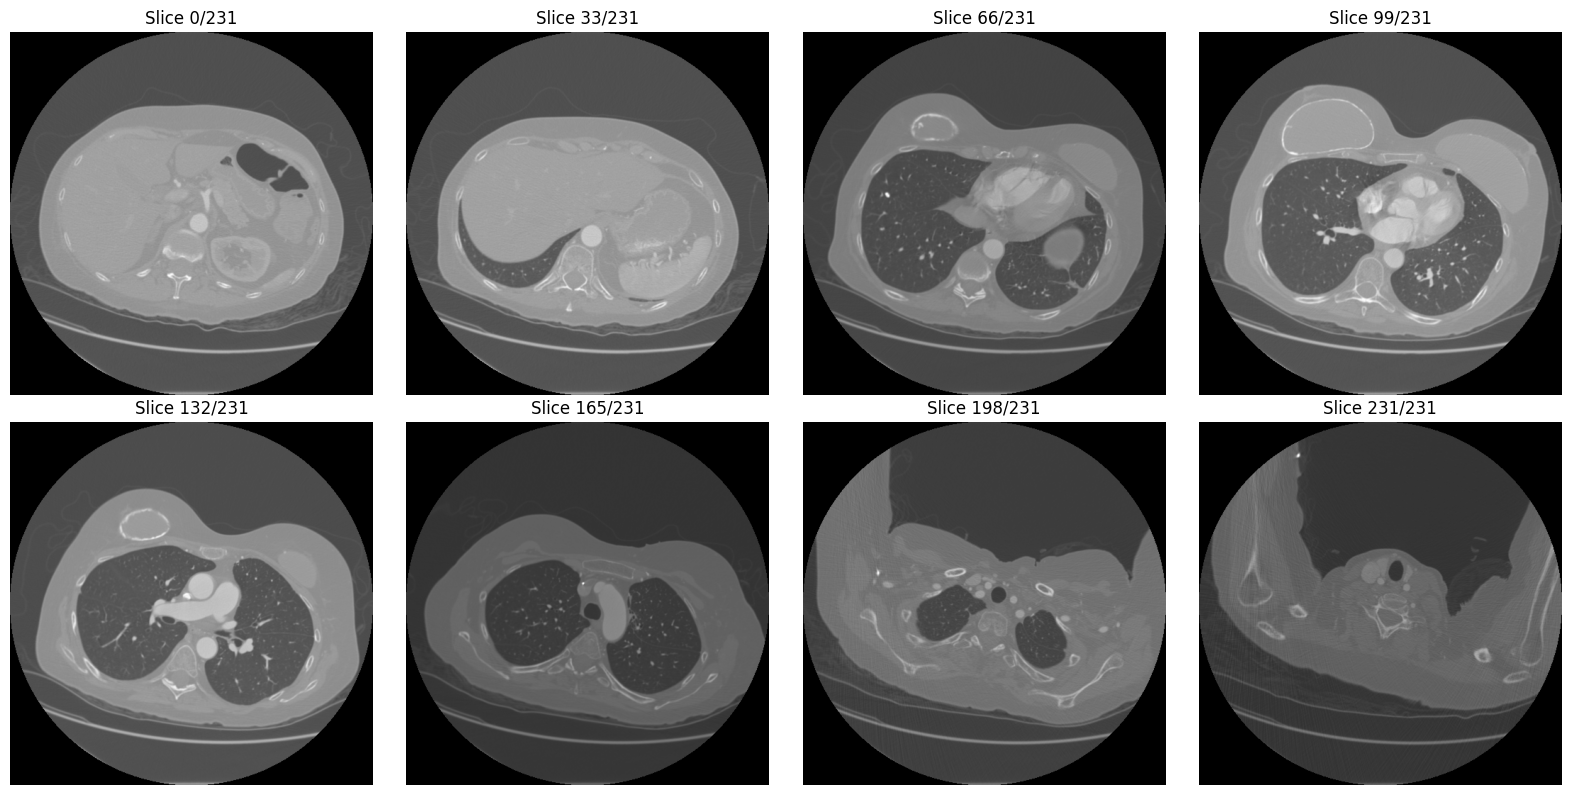

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

num_slices = ct_array.shape[0]
slice_indices = np.linspace(0, num_slices-1, 8, dtype=int)

for i, slice_idx in enumerate(slice_indices):
    axes[i].imshow(ct_array[slice_idx], cmap='gray')
    axes[i].set_title(f'Slice {slice_idx}/{num_slices-1}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [9]:
#World to Voxel Coordinate Conversion Function

def world_to_voxel(world_coords, origin, spacing):
    voxel_coords = np.abs(world_coords - origin) / spacing
    return voxel_coords.astype(int)

In [10]:
# Get Nodules then convert to coordinate to voxel space for sample scan

sample_annotations = annotations_subset0[annotations_subset0['seriesuid'] == sample_seriesuid]
sample_candidates = candidates_subset0[candidates_subset0['seriesuid'] == sample_seriesuid]

print(f"Nodules in this scan: {len(sample_annotations)}")
print("\nNodule locations (world coordinates):")
print(sample_annotations[['coordX', 'coordY', 'coordZ', 'diameter_mm']])

print(f"\nCandidates in this scan: {len(sample_candidates)}")
print(f"Positive: {sample_candidates['class'].sum()}")
print(f"Negative: {len(sample_candidates) - sample_candidates['class'].sum()}")

origin_array = np.array(origin)
spacing_array = np.array(spacing)

voxel_coords = []
for _, row in sample_annotations.iterrows():
    world_coord = np.array([row['coordX'], row['coordY'], row['coordZ']])
    voxel_coord = world_to_voxel(world_coord, origin_array, spacing_array)
    voxel_coords.append(voxel_coord)
    print(f"World: {world_coord} -> Voxel: {voxel_coord} (z, y, x: {voxel_coord[2]}, {voxel_coord[1]}, {voxel_coord[0]})")

voxel_coords = np.array(voxel_coords)

Nodules in this scan: 2

Nodule locations (world coordinates):
         coordX    coordY      coordZ  diameter_mm
792 -131.398795 -2.758456 -221.430605     5.673454
793   60.463657  6.684682 -166.263571     6.275342

Candidates in this scan: 780
Positive: 2
Negative: 778
World: [-131.3987948    -2.75845614 -221.4306053 ] -> Voxel: [118 229  66] (z, y, x: 66, 229, 118)
World: [  60.46365697    6.68468246 -166.2635713 ] -> Voxel: [391 242 110] (z, y, x: 110, 242, 391)


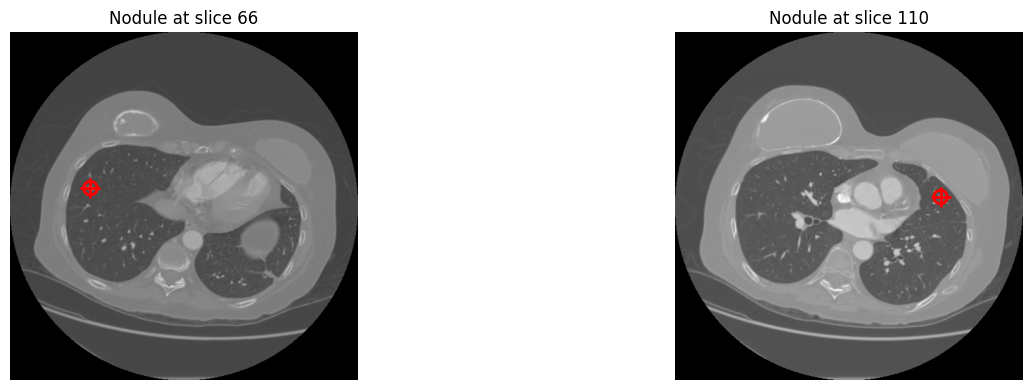

In [11]:
if len(voxel_coords) > 0:
    num_nodules = min(4, len(voxel_coords))
    fig, axes = plt.subplots(1, num_nodules, figsize=(16, 4))
    if num_nodules == 1:
        axes = [axes]
    
    for i in range(num_nodules):
        z, y, x = voxel_coords[i][2], voxel_coords[i][1], voxel_coords[i][0]
        
        axes[i].imshow(ct_array[z], cmap='gray')
        circle = plt.Circle((x, y), 10, color='red', fill=False, linewidth=2)
        axes[i].add_patch(circle)
        axes[i].plot(x, y, 'r+', markersize=15, markeredgewidth=2)
        axes[i].set_title(f'Nodule at slice {z}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

In [12]:
# Extract 3D Patch Around Nodule

def extract_patch(ct_array, center_voxel, patch_size=64):
    z, y, x = center_voxel[2], center_voxel[1], center_voxel[0]
    half_size = patch_size // 2
    
    z_min = max(0, z - half_size)
    z_max = min(ct_array.shape[0], z + half_size)
    y_min = max(0, y - half_size)
    y_max = min(ct_array.shape[1], y + half_size)
    x_min = max(0, x - half_size)
    x_max = min(ct_array.shape[2], x + half_size)
    
    patch = ct_array[z_min:z_max, y_min:y_max, x_min:x_max]
    
    padded_patch = np.zeros((patch_size, patch_size, patch_size))
    
    z_start = (patch_size - patch.shape[0]) // 2
    y_start = (patch_size - patch.shape[1]) // 2
    x_start = (patch_size - patch.shape[2]) // 2
    
    padded_patch[z_start:z_start+patch.shape[0],
                 y_start:y_start+patch.shape[1],
                 x_start:x_start+patch.shape[2]] = patch
    
    return padded_patch

if len(voxel_coords) > 0:
    sample_patch = extract_patch(ct_array, voxel_coords[0], patch_size=64)
    print(f"Patch shape: {sample_patch.shape}")
    print(f"Patch intensity range: [{sample_patch.min()}, {sample_patch.max()}]")

Patch shape: (64, 64, 64)
Patch intensity range: [-1024.0, 1912.0]


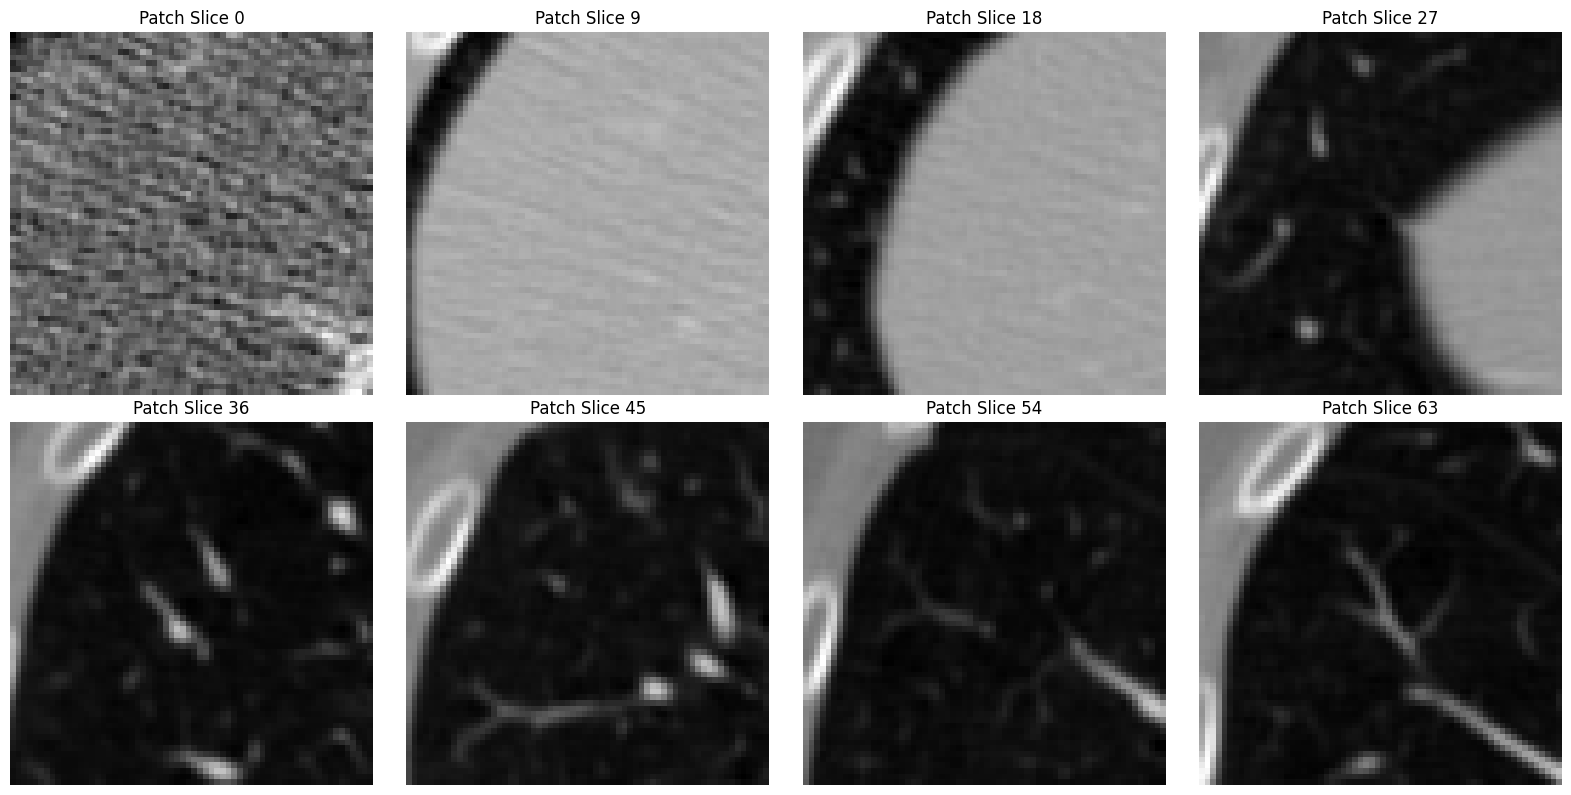

In [13]:
# 3D slide
if len(voxel_coords) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()
    
    patch_slices = np.linspace(0, sample_patch.shape[0]-1, 8, dtype=int)
    
    for i, slice_idx in enumerate(patch_slices):
        axes[i].imshow(sample_patch[slice_idx], cmap='gray')
        axes[i].set_title(f'Patch Slice {slice_idx}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

Normalized patch range: [0.000, 1.000]


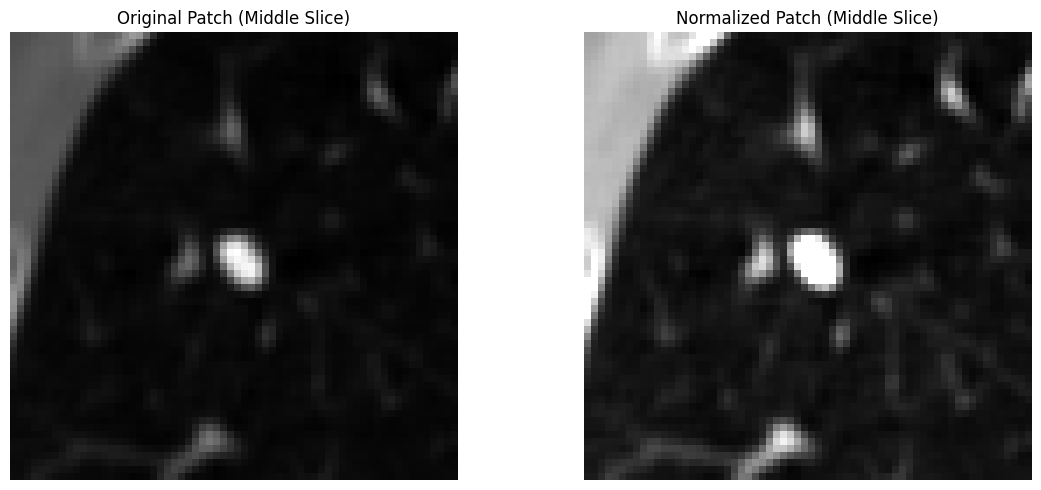

In [14]:
# Normalize Patch (HU Windowing)

def normalize_hu(patch, min_hu=-1000, max_hu=400):
    patch = np.clip(patch, min_hu, max_hu)
    patch = (patch - min_hu) / (max_hu - min_hu)
    return patch

if len(voxel_coords) > 0:
    normalized_patch = normalize_hu(sample_patch)
    print(f"Normalized patch range: [{normalized_patch.min():.3f}, {normalized_patch.max():.3f}]")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    mid_slice = sample_patch.shape[0] // 2
    axes[0].imshow(sample_patch[mid_slice], cmap='gray')
    axes[0].set_title('Original Patch (Middle Slice)')
    axes[0].axis('off')
    
    axes[1].imshow(normalized_patch[mid_slice], cmap='gray')
    axes[1].set_title('Normalized Patch (Middle Slice)')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

In [15]:
print(f"\nTotal CT scans in subset0: {len(mhd_files)}")
print(f"Total annotations in subset0: {len(annotations_subset0)}")
print(f"Total candidates in subset0: {len(candidates_subset0)}")
print(f"  - Positive (nodules): {candidates_subset0['class'].sum()}")
print(f"  - Negative (non-nodules): {len(candidates_subset0) - candidates_subset0['class'].sum()}")
print(f"\nClass distribution:")
print(candidates_subset0['class'].value_counts())
print(f"\nNodule diameter statistics (mm):")
print(annotations_subset0['diameter_mm'].describe())


Total CT scans in subset0: 89
Total annotations in subset0: 112
Total candidates in subset0: 79135
  - Positive (nodules): 138
  - Negative (non-nodules): 78997

Class distribution:
class
0    78997
1      138
Name: count, dtype: int64

Nodule diameter statistics (mm):
count    112.000000
mean       8.267130
std        4.216307
min        3.604122
25%        5.251964
50%        6.755718
75%       10.162047
max       25.233202
Name: diameter_mm, dtype: float64


# 2. Data preprocessing

In [16]:
#Dataset Generation Function

def load_ct_scan(seriesuid, subset_path):
    path = Path(subset_path) / f"{seriesuid}.mhd"
    ct_scan = sitk.ReadImage(str(path))
    ct_array = sitk.GetArrayFromImage(ct_scan)
    origin = np.array(ct_scan.GetOrigin())
    spacing = np.array(ct_scan.GetSpacing())
    return ct_array, origin, spacing

def get_candidates_for_scan(seriesuid, candidates_df):
    return candidates_df[candidates_df['seriesuid'] == seriesuid]

def extract_candidate_patch(ct_array, world_coord, origin, spacing, patch_size=64):
    voxel_coord = world_to_voxel(world_coord, origin, spacing)
    patch = extract_patch(ct_array, voxel_coord, patch_size)
    normalized_patch = normalize_hu(patch)
    return normalized_patch

In [17]:
#Generate Dataset (limited)

PATCH_SIZE = 32
NUM_SCANS_TO_USE = 50

all_patches = []
all_labels = []
all_seriesuid = []

selected_scans = subset0_seriesuid[:NUM_SCANS_TO_USE]

print(f"Generating dataset from {NUM_SCANS_TO_USE} scans...")

for idx, seriesuid in enumerate(selected_scans):
    try:
        ct_array, origin, spacing = load_ct_scan(seriesuid, SUBSET_PATH)
        scan_candidates = get_candidates_for_scan(seriesuid, candidates_subset0)
        
        for _, row in scan_candidates.iterrows():
            world_coord = np.array([row['coordX'], row['coordY'], row['coordZ']])
            patch = extract_candidate_patch(ct_array, world_coord, origin, spacing, PATCH_SIZE)
            
            all_patches.append(patch)
            all_labels.append(row['class'])
            all_seriesuid.append(seriesuid)
        
        print(f"Processed {idx + 1}/{NUM_SCANS_TO_USE} scans, Total patches: {len(all_patches)}")
    
    except Exception as e:
        print(f"Error processing {seriesuid}: {e}")
        continue

print(f"\nDataset generation complete!")
print(f"Total patches: {len(all_patches)}")
print(f"Positive samples: {sum(all_labels)}")
print(f"Negative samples: {len(all_labels) - sum(all_labels)}")

Generating dataset from 50 scans...
Processed 1/50 scans, Total patches: 780
Processed 2/50 scans, Total patches: 2111
Processed 3/50 scans, Total patches: 3194
Processed 4/50 scans, Total patches: 4156
Processed 5/50 scans, Total patches: 4628
Processed 6/50 scans, Total patches: 5661
Processed 7/50 scans, Total patches: 6817
Processed 8/50 scans, Total patches: 7207
Processed 9/50 scans, Total patches: 7912
Processed 10/50 scans, Total patches: 8499
Processed 11/50 scans, Total patches: 9212
Processed 12/50 scans, Total patches: 9997
Processed 13/50 scans, Total patches: 11016
Processed 14/50 scans, Total patches: 11727
Processed 15/50 scans, Total patches: 12270
Processed 16/50 scans, Total patches: 13325
Processed 17/50 scans, Total patches: 13845
Processed 18/50 scans, Total patches: 14552
Processed 19/50 scans, Total patches: 15521
Processed 20/50 scans, Total patches: 16725
Processed 21/50 scans, Total patches: 17821
Processed 22/50 scans, Total patches: 18711
Processed 23/50 sc

In [18]:
X = np.array(all_patches)
y = np.array(all_labels)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X dtype: {X.dtype}")
print(f"y dtype: {y.dtype}")
print(f"X memory size: {X.nbytes / 1024**2:.2f} MB")

X shape: (44758, 32, 32, 32)
y shape: (44758,)
X dtype: float64
y dtype: int64
X memory size: 11189.50 MB


In [19]:
# Balance Dataset (Undersample Negatives)

positive_indices = np.where(y == 1)[0]
negative_indices = np.where(y == 0)[0]

print(f"Positive samples: {len(positive_indices)}")
print(f"Negative samples: {len(negative_indices)}")

if len(positive_indices) > 0:
    np.random.seed(42)
    num_negatives_to_select = min(len(positive_indices) * 10, len(negative_indices))
    selected_negative_indices = np.random.choice(negative_indices, size=num_negatives_to_select, replace=False)
    
    balanced_indices = np.concatenate([positive_indices, selected_negative_indices])
    np.random.shuffle(balanced_indices)
    
    X_balanced = X[balanced_indices]
    y_balanced = y[balanced_indices]
    
    print(f"\nBalanced dataset:")
    print(f"X_balanced shape: {X_balanced.shape}")
    print(f"y_balanced shape: {y_balanced.shape}")
    print(f"Positive: {np.sum(y_balanced == 1)}")
    print(f"Negative: {np.sum(y_balanced == 0)}")
    print(f"Ratio: 1:{np.sum(y_balanced == 0) / np.sum(y_balanced == 1):.1f}")
else:
    print("No positive samples found in the selected scans!")
    X_balanced = X
    y_balanced = y

Positive samples: 72
Negative samples: 44686

Balanced dataset:
X_balanced shape: (792, 32, 32, 32)
y_balanced shape: (792,)
Positive: 72
Negative: 720
Ratio: 1:10.0


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_balanced, y_balanced, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_balanced
)

print(f"Training set:")
print(f"  X_train shape: {X_train.shape}")
print(f"  Positive: {np.sum(y_train == 1)}")
print(f"  Negative: {np.sum(y_train == 0)}")

print(f"\nValidation set:")
print(f"  X_val shape: {X_val.shape}")
print(f"  Positive: {np.sum(y_val == 1)}")
print(f"  Negative: {np.sum(y_val == 0)}")

Training set:
  X_train shape: (633, 32, 32, 32)
  Positive: 58
  Negative: 575

Validation set:
  X_val shape: (159, 32, 32, 32)
  Positive: 14
  Negative: 145


In [21]:
# Reshape for Model Input (Add Channel Dimension)
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")

X_train shape: (633, 32, 32, 32, 1)
X_val shape: (159, 32, 32, 32, 1)


# 3. Model

In [22]:
def build_3d_cnn(input_shape=(32, 32, 32, 1)):
    inputs = keras.Input(shape=input_shape)
    
    x = layers.Conv3D(32, kernel_size=3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling3D(pool_size=2)(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Conv3D(64, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.MaxPooling3D(pool_size=2)(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Conv3D(128, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.MaxPooling3D(pool_size=2)(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.GlobalAveragePooling3D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

model = build_3d_cnn()
model.summary()

I0000 00:00:1770177640.850768    1671 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 32, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 32, 32, 32, 32) │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 16, 16, 16, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 16, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 16, 16, 16, 64) │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 8, 8, 8, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 8, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 8, 8, 8, 128)   │       221,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 4, 4, 4, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 4, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling3d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling3D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295,105 (1.13 MB)

 Trainable params: 294,657 (1.12 MB)

 Non-trainable params: 448 (1.75 KB)

In [23]:
# Compile Model

pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)
print(f"Positive class weight: {pos_weight:.2f}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.BinaryAccuracy(name='accuracy'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

print("Model compiled successfully")

Positive class weight: 9.91
Model compiled successfully


In [24]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1,
        min_lr=1e-6
    )
]

# 4. Training

In [25]:
EPOCHS = 50
BATCH_SIZE = 8

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    class_weight={0: 1.0, 1: pos_weight},
    verbose=1
)

Epoch 1/50


I0000 00:00:1770177646.060431    1721 service.cc:152] XLA service 0x7a4938013180 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770177646.060469    1721 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1770177646.708604    1721 cuda_dnn.cc:529] Loaded cuDNN version 91002


13/80 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6855 - auc: 0.6534 - loss: 1.1740 - precision: 0.1138 - recall: 0.5442

I0000 00:00:1770177651.459955    1721 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 85ms/step - accuracy: 0.6485 - auc: 0.5625 - loss: 1.4553 - precision: 0.1201 - recall: 0.4535 - val_accuracy: 0.0881 - val_auc: 0.6416 - val_loss: 1.7355 - val_precision: 0.0881 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5596 - auc: 0.6104 - loss: 1.4911 - precision: 0.1302 - recall: 0.6032 - val_accuracy: 0.1509 - val_auc: 0.6562 - val_loss: 1.3314 - val_precision: 0.0940 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7177 - auc: 0.6854 - loss: 1.1238 - precision: 0.1674 - recall: 0.6568 - val_accuracy: 0.7233 - val_auc: 0.6182 - val_loss: 0.6128 - val_precision: 0.1591 - val_recall: 0.5000 - learning_rate: 0.0010
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6166 - auc: 0.7172 - loss: 1.1702 - precision: 0.1769 - recall: 0.7768 - val_accuracy: 0.3711 - val_auc: 0.6101 - val_loss: 1.0735 - val_precision: 0.

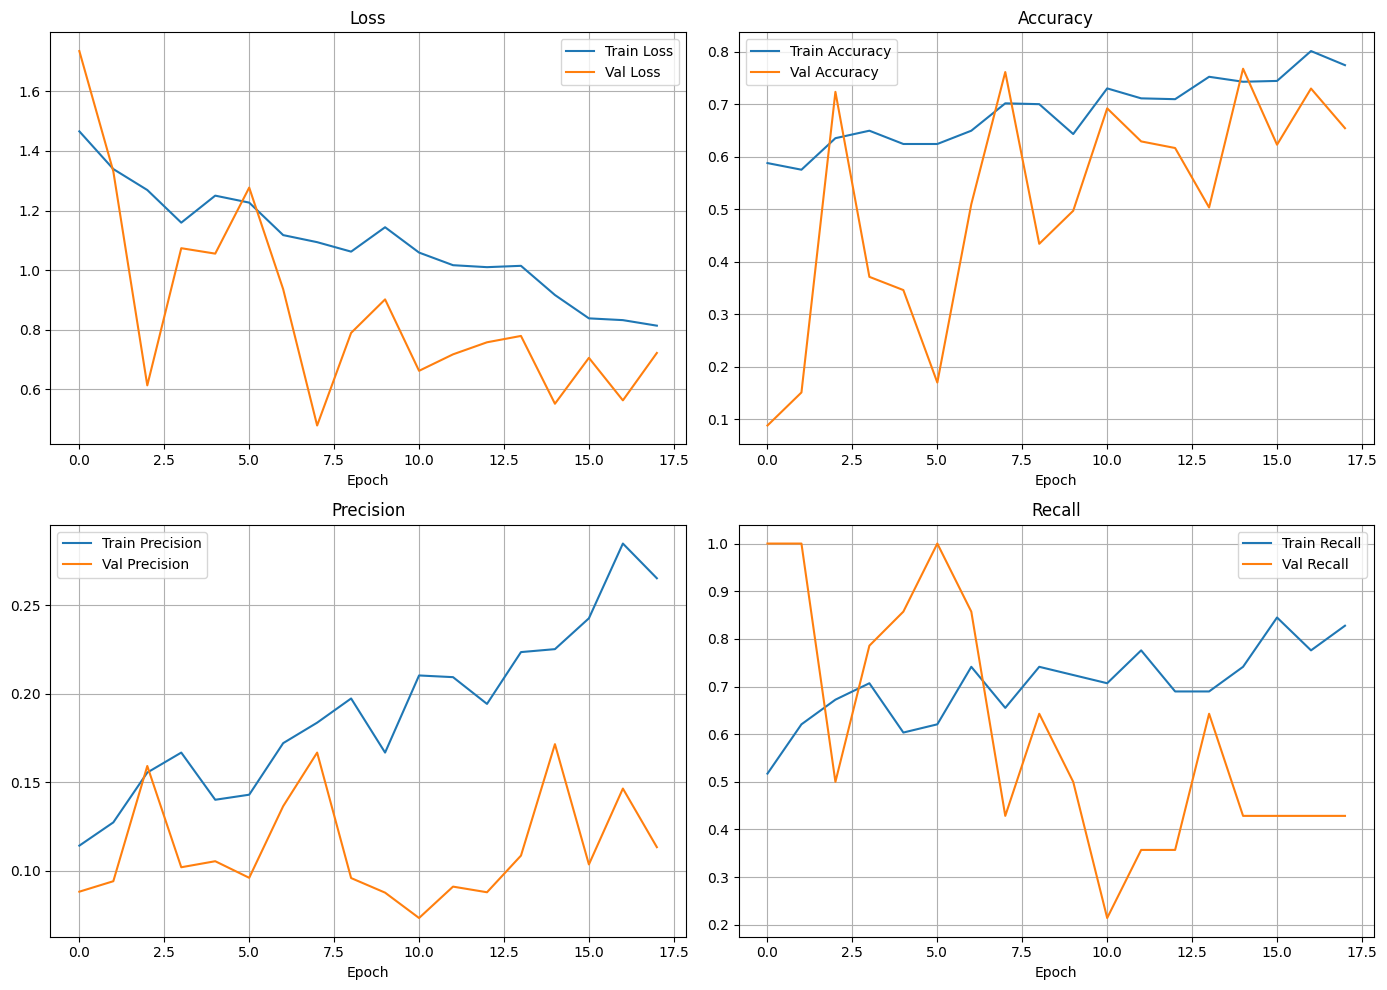

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(history.history['loss'], label='Train Loss')
axes[0, 0].plot(history.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy')
axes[0, 1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0, 1].set_title('Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(history.history['precision'], label='Train Precision')
axes[1, 0].plot(history.history['val_precision'], label='Val Precision')
axes[1, 0].set_title('Precision')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(history.history['recall'], label='Train Recall')
axes[1, 1].plot(history.history['val_recall'], label='Val Recall')
axes[1, 1].set_title('Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [27]:
# Evaluate on Validation Set

val_loss, val_accuracy, val_precision, val_recall, val_auc = model.evaluate(X_val, y_val, verbose=0)

print("="*60)
print("VALIDATION RESULTS")
print("="*60)
print(f"Loss:      {val_loss:.4f}")
print(f"Accuracy:  {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall:    {val_recall:.4f}")
print(f"AUC:       {val_auc:.4f}")
print(f"F1-Score:  {2 * (val_precision * val_recall) / (val_precision + val_recall):.4f}")

VALIDATION RESULTS
Loss:      0.4781
Accuracy:  0.7610
Precision: 0.1667
Recall:    0.4286
AUC:       0.6456
F1-Score:  0.2400


### 4.1 Augumentation

### 4.2 Class Imbalance

# 4.3 Metrics

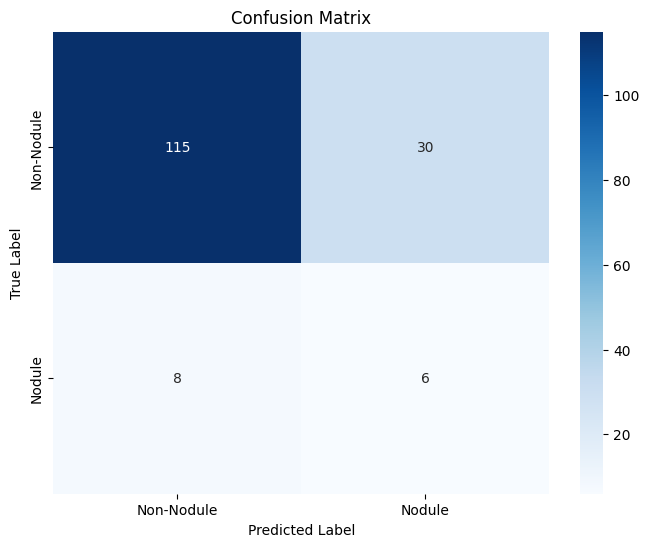


Classification Report:
              precision    recall  f1-score   support

  Non-Nodule       0.93      0.79      0.86       145
      Nodule       0.17      0.43      0.24        14

    accuracy                           0.76       159
   macro avg       0.55      0.61      0.55       159
weighted avg       0.87      0.76      0.80       159



In [28]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_proba = model.predict(X_val, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Nodule', 'Nodule'],
            yticklabels=['Non-Nodule', 'Nodule'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['Non-Nodule', 'Nodule']))

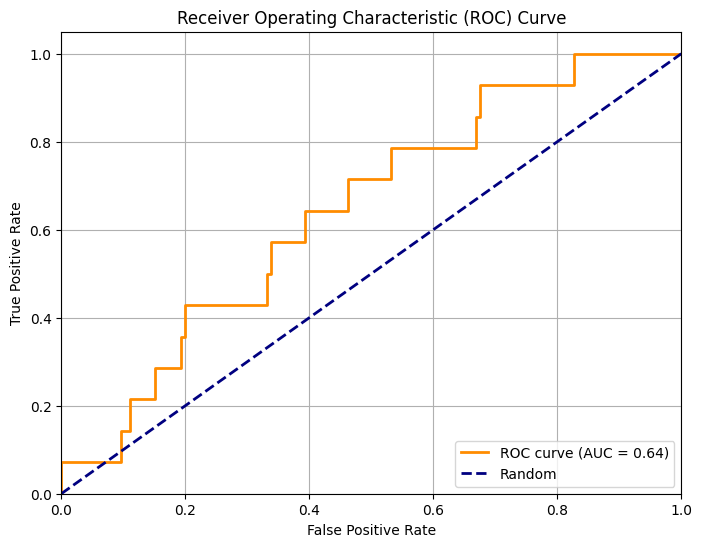

In [29]:
# ROC Curve

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
roc_auc = roc_auc_score(y_val, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

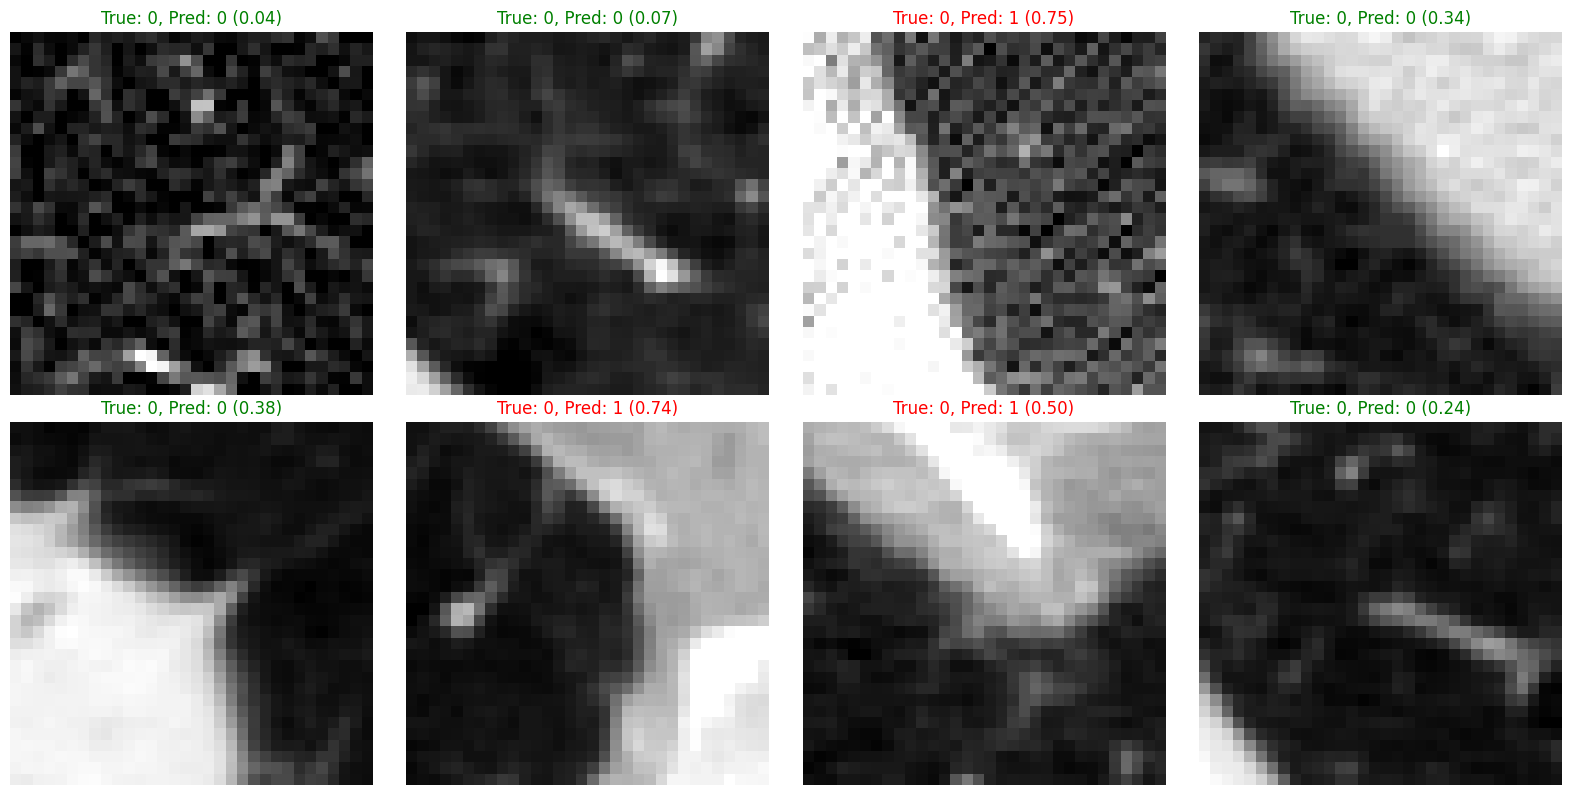

In [30]:
# Visualize Predictions on Sample Patches

num_samples = 8
sample_indices = np.random.choice(len(X_val), num_samples, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, idx in enumerate(sample_indices):
    patch = X_val[idx, :, :, :, 0]
    true_label = y_val[idx]
    pred_proba = y_pred_proba[idx][0]
    pred_label = int(pred_proba > 0.5)
    
    mid_slice = patch.shape[0] // 2
    axes[i].imshow(patch[mid_slice], cmap='gray')
    
    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(f'True: {true_label}, Pred: {pred_label} ({pred_proba:.2f})', color=color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [31]:
model.save('nodule_detection_3dcnn.h5')
print("Model saved as 'nodule_detection_3dcnn.h5'")

Model saved as 'nodule_detection_3dcnn.h5'
